In [3]:
import pandas as pd
import numpy as np

## Data loading and Cleaning

In [4]:
df=pd.read_csv("retail_sales_dataset.csv")
df.head(10)

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100
5,6,2023-04-25,CUST006,Female,45,Beauty,1,30,30
6,7,2023-03-13,CUST007,Male,46,Clothing,2,25,50
7,8,2023-02-22,CUST008,Male,30,Electronics,4,25,100
8,9,2023-12-13,CUST009,Male,63,Electronics,2,300,600
9,10,2023-10-07,CUST010,Female,52,Clothing,4,50,200


In [5]:
df.isnull().sum()


Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

The data has no missing values 

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    1000 non-null   int64
 1   Date              1000 non-null   str  
 2   Customer ID       1000 non-null   str  
 3   Gender            1000 non-null   str  
 4   Age               1000 non-null   int64
 5   Product Category  1000 non-null   str  
 6   Quantity          1000 non-null   int64
 7   Price per Unit    1000 non-null   int64
 8   Total Amount      1000 non-null   int64
dtypes: int64(5), str(4)
memory usage: 70.4 KB


In [8]:
df['Date']=pd.to_datetime(df['Date'])

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[us]
 2   Customer ID       1000 non-null   str           
 3   Gender            1000 non-null   str           
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   str           
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
dtypes: datetime64[us](1), int64(5), str(3)
memory usage: 70.4 KB


#changed the datatype of Date column from 'str' to 'datetime' format 

In [10]:
df.columns
df['Product Category'].unique()

<StringArray>
['Beauty', 'Clothing', 'Electronics']
Length: 3, dtype: str

In [11]:
df['Total Amount'].mode()

0    50
Name: Total Amount, dtype: int64

## Descriptive Statistics

In [12]:
df.describe()

,Transaction ID,Date,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,2023-07-03 00:25:55.200000,41.39200,2.514000,179.890000,456.000000
min,1.000000,2023-01-01 00:00:00,18.00000,1.000000,25.000000,25.000000
25%,250.750000,2023-04-08 00:00:00,29.00000,1.000000,30.000000,60.000000
50%,500.500000,2023-06-29 12:00:00,42.00000,3.000000,50.000000,135.000000
75%,750.250000,2023-10-04 00:00:00,53.00000,4.000000,300.000000,900.000000
max,1000.000000,2024-01-01 00:00:00,64.00000,4.000000,500.000000,2000.000000
std,288.819436,NaN,13.68143,1.132734,189.681356,559.997632


### Central Tendency Analysis.   
#### 1. Mean Vs Median  = The Mean Total Amount is 456.0 ,and Median is 135.0 , this shows Mean is higher than Median so the data is right skewed . The ouliers like Max of 2000.0 is pulling the average up .

#### 2. The average customer age is 41 ,and Median is at 42, so the primary customer base is middle aged 

### Dispersion  
#### Price per unit = The std(standard deviation) is 189.68, which is high compared to mean 179, This indicates a huge variety in product prices

## Time Series Analysis

In [13]:
df.set_index('Date',inplace =True)

In [14]:
df['Year']=df.index.year
df['Month']=df.index.month_name()
df.head()


,Transaction ID,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Year,Month
Date,,,,,,,,,,
2023-11-24,1,CUST001,Male,34,Beauty,3,50,150,2023,November
2023-02-27,2,CUST002,Female,26,Clothing,2,500,1000,2023,February
2023-01-13,3,CUST003,Male,50,Electronics,1,30,30,2023,January
2023-05-21,4,CUST004,Male,37,Clothing,1,500,500,2023,May
2023-05-06,5,CUST005,Male,30,Beauty,2,50,100,2023,May


In [15]:
df.head(10)

,Transaction ID,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Year,Month
Date,,,,,,,,,,
2023-11-24,1,CUST001,Male,34,Beauty,3,50,150,2023,November
2023-02-27,2,CUST002,Female,26,Clothing,2,500,1000,2023,February
2023-01-13,3,CUST003,Male,50,Electronics,1,30,30,2023,January
2023-05-21,4,CUST004,Male,37,Clothing,1,500,500,2023,May
2023-05-06,5,CUST005,Male,30,Beauty,2,50,100,2023,May
2023-04-25,6,CUST006,Female,45,Beauty,1,30,30,2023,April
2023-03-13,7,CUST007,Male,46,Clothing,2,25,50,2023,March
2023-02-22,8,CUST008,Male,30,Electronics,4,25,100,2023,February
2023-12-13,9,CUST009,Male,63,Electronics,2,300,600,2023,December


In [16]:
# group by Month and sum the  Total Amount
monthly_sales = df.groupby('Month')['Total Amount'].sum().reset_index()
print(monthly_sales)

        Month  Total Amount
0       April         33870
1      August         36960
2    December         44690
3    February         44060
4     January         36980
5        July         35465
6        June         36715
7       March         28990
8         May         53150
9    November         34920
10    October         46580
11  September         23620


In [17]:
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
monthly_sales['Month'] = pd.Categorical(monthly_sales['Month'],categories = month_order,ordered = True)
monthly_sales = monthly_sales.sort_values('Month')

In [18]:
df.head()

,Transaction ID,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Year,Month
Date,,,,,,,,,,
2023-11-24,1,CUST001,Male,34,Beauty,3,50,150,2023,November
2023-02-27,2,CUST002,Female,26,Clothing,2,500,1000,2023,February
2023-01-13,3,CUST003,Male,50,Electronics,1,30,30,2023,January
2023-05-21,4,CUST004,Male,37,Clothing,1,500,500,2023,May
2023-05-06,5,CUST005,Male,30,Beauty,2,50,100,2023,May


In [19]:
monthly_sales.head(12)

,Month,Total Amount
4,January,36980
3,February,44060
7,March,28990
0,April,33870
8,May,53150
6,June,36715
5,July,35465
1,August,36960
11,September,23620
10,October,46580


#### Time series Visalization


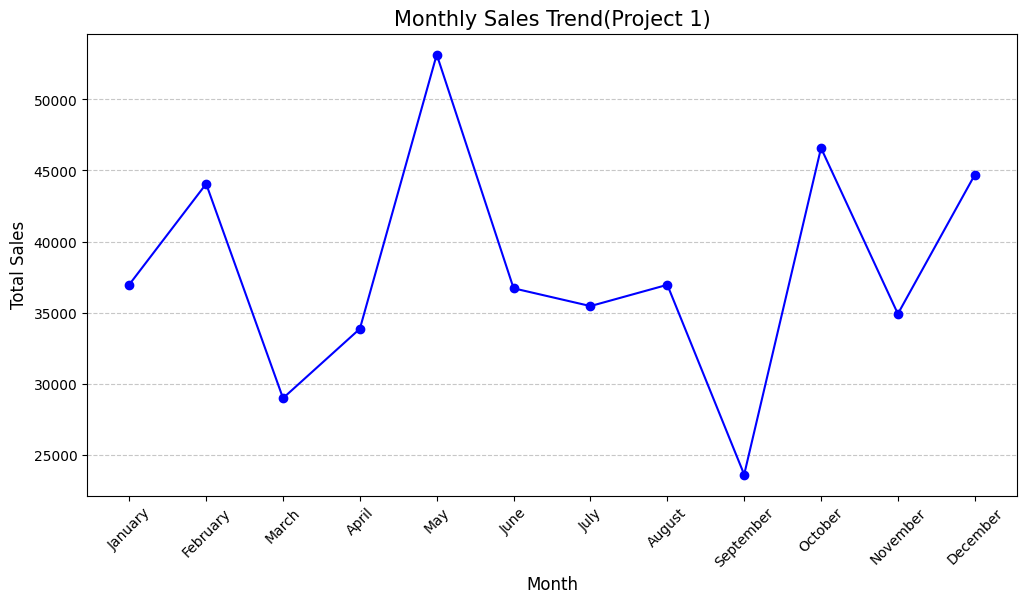

In [20]:
# Representing the Time series Analysis through a Line chart  
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
plt.plot(monthly_sales['Month'],monthly_sales['Total Amount'],marker='o',linestyle='-',color='blue')
plt.title('Monthly Sales Trend(Project 1)',fontsize=15)
plt.xlabel('Month',fontsize=12)
plt.ylabel('Total Sales',fontsize=12)
plt.grid(axis='y',linestyle='--',alpha=0.7)
plt.xticks(rotation=45)
plt.show()


In [21]:
df.head()

,Transaction ID,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Year,Month
Date,,,,,,,,,,
2023-11-24,1,CUST001,Male,34,Beauty,3,50,150,2023,November
2023-02-27,2,CUST002,Female,26,Clothing,2,500,1000,2023,February
2023-01-13,3,CUST003,Male,50,Electronics,1,30,30,2023,January
2023-05-21,4,CUST004,Male,37,Clothing,1,500,500,2023,May
2023-05-06,5,CUST005,Male,30,Beauty,2,50,100,2023,May


## Customer Demographics and Purchasing Behaviour Analysis

In [22]:
# who spends more time per vist male or female?

Gender_Analysis = df.groupby('Gender')['Total Amount'].mean()
print(Gender_Analysis)

Gender
Female    456.549020
Male      455.428571
Name: Total Amount, dtype: float64


In [23]:
# which age group spends the most?

Age_analysis = df.groupby('Age')['Total Amount'].sum().sort_values(ascending=False).head(10)
print(Age_analysis)

Age
43    17970
34    16785
51    16065
19    14870
26    13980
22    13700
46    13090
21    12585
47    12505
37    11650
Name: Total Amount, dtype: int64


In [24]:
# which category collects more profit?

Category_analysis = df.groupby('Product Category').agg({'Total Amount':'sum','Quantity':'sum'})
print(Category_analysis)

                  Total Amount  Quantity
Product Category                        
Beauty                  143515       771
Clothing                155580       894
Electronics             156905       849


In [25]:
# what do mens buy Vs what do womens buy?

Pivot_report = df.pivot_table(index='Gender',columns= 'Product Category',values='Total Amount',aggfunc='sum')
print(Pivot_report)

Product Category  Beauty  Clothing  Electronics
Gender                                         
Female             74830     81275        76735
Male               68685     74305        80170


In [26]:
# Does spending behavior change by Gender for different Products?
behavior_pivot = df.pivot_table(index='Gender', 
                                columns='Product Category', 
                                values='Total Amount', 
                                aggfunc='sum')

print("Spending Behavior (Gender vs Product Category):\n", behavior_pivot)

Spending Behavior (Gender vs Product Category):
 Product Category  Beauty  Clothing  Electronics
Gender                                         
Female             74830     81275        76735
Male               68685     74305        80170


## Visualization

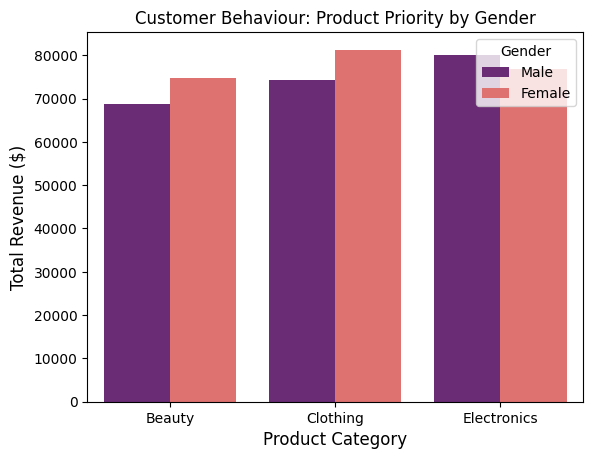

In [38]:
# Barchart for pivot report(product- priorities for male's and female's)

import seaborn as sns
import matplotlib.pyplot as plt

plt.Figure(figsize=(12,10))
sns.barplot(
    data=df,
    x='Product Category',
    y='Total Amount',
    hue='Gender',
    estimator=sum,
    errorbar=None,
    palette='magma'

)
plt.title('Customer Behaviour: Product Priority by Gender',fontsize=12)
plt.xlabel('Product Category',fontsize=12)
plt.ylabel('Total Revenue ($)',fontsize=12)
plt.show()

C:\Users\Deepanshu Rai\AppData\Local\Temp\ipykernel_15348\310911769.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


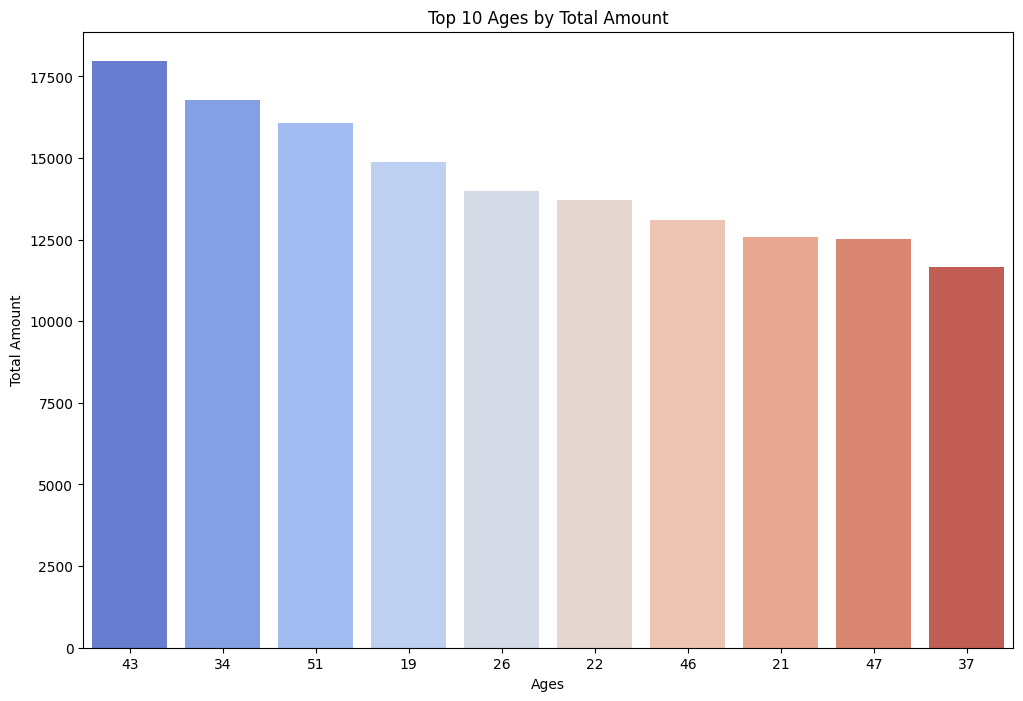

In [39]:
# Barchart for Age analysis (Top 10 Ages by Total Amount)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.barplot(

    x=Age_analysis.index,
    y=Age_analysis.values,
    palette='coolwarm',
    order=Age_analysis.index,

)
plt.title('Top 10 Ages by Total Amount',fontsize=12)
plt.xlabel('Ages')
plt.ylabel('Total Amount')
plt.show()

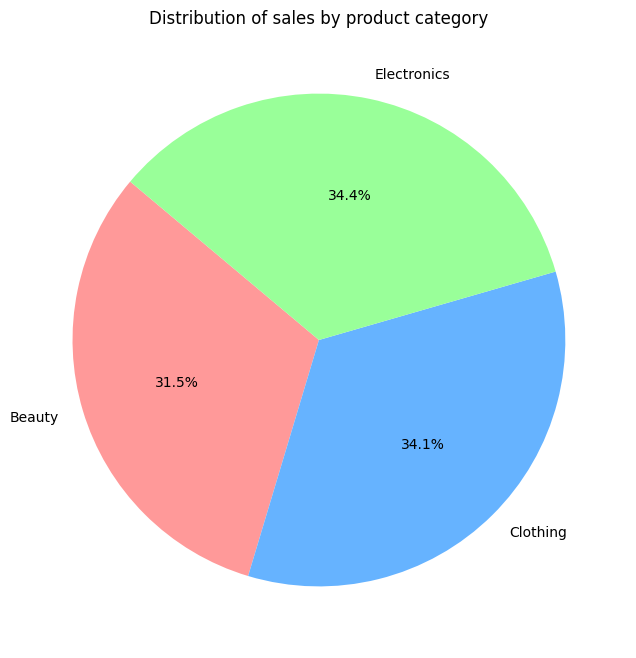

In [45]:
# creating a pie chart for product category distribution

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,8))

plt.pie(
    Category_analysis['Total Amount'],
    labels=Category_analysis.index,
    autopct='%1.1f%%',
    colors=['#ff9999','#66b3ff','#99ff99'],
    startangle=140
)
plt.title('Distribution of sales by product category',fontsize=12)
plt.show()

## Recommendation 

### Based on the Exploratary Data Analysis (EDA) of the retail sales Dataset ,the following strategic recommendation's are proposed  

### Targeted Marketing for High value Age Group

##### 1- Insights = Our Analysis shows that ages 43,34 and 51 are the top spenders.

##### 2- Recommendations = The marketing team should create targeted social campaings specially for the age group 35-55 demographic, as     they have the highest purchasing power

### Inventory optimization 

##### 1- Insights = Electronics and Clothing contribute most to the total revenue 

##### 2- Recommendations = Ensure higher stock level for these three category during  peak season to prevent "Out Of Stock" scenerio.

### Personalized Customer Experience

##### 1- Insights = There is a clear distinction in product priorities between Male and Female customers.

##### 2- Recommendations = Implement a personalized email marketing system. For example, send "New Arrival" notifications for Clothing to female customers and Electronics updates to male customers based on their historical preference.